# WRP Simulation: Lodewijkstraat

This notebook acts as the main execution script. It imports the itinerary generator (`Entity.py`) and the Discrete Event Simulation engine (`DSE.py`), translates the data between them, and runs the required scenarios (Baseline vs +20% capacity).

### Priority Routing Note:
In `DSE.py`, upstream priority is determined by the order in which `.connect()` is called. To ensure `Rest` pulls from `DcDd` before `Hall/Overflow`, we simply execute `dcdd.connect(rest)` *before* `hall_overflow.connect(rest)`.

In [158]:
%load_ext autoreload
%autoreload 2

import numpy as np
from Entity import CustomerItineraryGenerator
from DSE import (
    Environment, LocationType, QueueLocation, 
    ServiceLocation, VehicleSize, Location, ItineraryItem
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Adapter: Translating Entity.py to DSE.py
Your partner's code generates routes as a list of integers (0 to 5). Our `DSE.py` requires `Customer` objects containing `ItineraryItem` objects with `LocationType` Enums. This function bridges that gap, mapping 'Hall' to the Hall Overflow bays and injecting the physical Hall Queue choke point.

In [159]:
def generate_dse_customers(num_customers):
    generator = CustomerItineraryGenerator()
    dse_customers = []
    
    # Map the partner's "Hall" (1) to the HALL_OVERFLOW service area. 
    location_map = {
        0: LocationType.MAIN_QUEUE, 
        1: LocationType.HALL_OVERFLOW, 
        2: LocationType.DCDD, 
        3: LocationType.GREEN,
        4: LocationType.REST, 
        5: LocationType.EXIT
    }

    service_times = {
        LocationType.MAIN_QUEUE: 0, 
        LocationType.HALL_QUEUE: 0,       # It's a queue, no inherent service time
        LocationType.HALL_OVERFLOW: 240,  # Service time for the hall bays
        LocationType.DCDD: 331,
        LocationType.GREEN: 341, 
        LocationType.REST: 141, 
        LocationType.EXIT: 0
    }

    arrival_clock = 0.0

    for _ in range(num_customers):
        raw_itinerary = generator.Next()
        v_size = VehicleSize.BIG if np.random.rand() < 0.47 else VehicleSize.SMALL
        
        dse_itinerary = []
        for i, loc_int in enumerate(raw_itinerary):
            loc_enum = location_map[loc_int]
            item = ItineraryItem(location=loc_enum, service_time=service_times[loc_enum])
            
            # Set the actual arrival time ONLY for their first stop (Entrance)
            if i == 0:
                item.start_time = arrival_clock
                
            dse_itinerary.append(item)
            
            # NEW LOGIC: Inject the physical HALL_QUEUE right after they enter the MAIN_QUEUE
            if i == 0:
                dse_itinerary.append(ItineraryItem(location=LocationType.HALL_QUEUE, service_time=0))
                
        import DSE 
        dse_customers.append(DSE.Customer(dse_itinerary, v_size))
        
        # Space out the next vehicle using an exponential distribution
        # 28800 seconds / 605 cars = ~47.6 sec average gap
        arrival_clock += np.random.exponential(28800 / num_customers) 
        
    return dse_customers

### 2. Network Configuration
We instantiate the locations and establish the routing graph. This explicitly defines the 14-capacity `HALL_QUEUE` and connects all necessary downstream pathways.

In [160]:
def setup_environment(customers):
    # 1. Instantiate Locations
    # Entrance
    entrance = QueueLocation(LocationType.MAIN_QUEUE, maximum_capacity=99999)
    
    # Hall Queue (Strict limit: 14 small cars)
    hall_queue = QueueLocation(LocationType.HALL_QUEUE, maximum_capacity=14)
    
    # Hall Overflow (The actual service bays for "Hall")
    hall_pairs = [[i, i+1] for i in range(0, 12, 2)]
    hall_overflow = ServiceLocation(LocationType.HALL_OVERFLOW, max_capacity=12, single_bays=22, single_bay_pairs=hall_pairs)
    
    # DcDd: 7 single bays
    dcdd_pairs = [[0, 1], [2, 3], [4, 5]]
    dcdd = ServiceLocation(LocationType.DCDD, max_capacity=7, single_bays=7, single_bay_pairs=dcdd_pairs)
    
    # Green & Rest: 5 single bays each
    green_pairs = [[0, 1], [1, 2], [2, 3], [3, 4]]
    green = ServiceLocation(LocationType.GREEN, max_capacity=5, single_bays=5, single_bay_pairs=green_pairs)
    
    rest_pairs = [[0, 1], [1, 2], [2, 3], [3, 4]]
    rest = ServiceLocation(LocationType.REST, max_capacity=5, single_bays=5, single_bay_pairs=[])
    
    # Exit Sink
    # Exit Sink (Now built as a QueueLocation so it respects itinerary routing!)
    exit_node = QueueLocation(LocationType.EXIT, maximum_capacity=999999)

    # 2. Connect Routing (ORDER DICTATES PRIORITY)
    # Entrance exclusively feeds into the Hall Queue
    entrance.connect(hall_queue)
    
    # Hall Queue feeds into the various service areas based on itinerary
    hall_queue.connect(hall_overflow)
    hall_queue.connect(dcdd)
    hall_queue.connect(green)
    hall_queue.connect(rest)
    hall_queue.connect(exit_node) # Direct to exit option

    # Internal cross-routing to REST
    dcdd.connect(rest)          # Priority 0
    green.connect(rest)         # Priority 1
    hall_overflow.connect(rest) # Priority 2
    
    # Internal cross-routing to DCDD
    hall_overflow.connect(dcdd)
    
    # All service locations connect to EXIT
    hall_overflow.connect(exit_node)
    dcdd.connect(exit_node)
    green.connect(exit_node)
    rest.connect(exit_node)

    # Pack into dictionary for Environment
    locations_dict = {
        LocationType.MAIN_QUEUE: entrance,
        LocationType.HALL_QUEUE: hall_queue,
        LocationType.HALL_OVERFLOW: hall_overflow,
        LocationType.DCDD: dcdd,
        LocationType.GREEN: green,
        LocationType.REST: rest,
        LocationType.EXIT: exit_node
    }
    
    return Environment(customers, locations_dict, initial_time=0)

### 3. Scenario 1: Baseline (605 Cars per Day)

In [161]:
num = 2000

print("--- Building Baseline Scenario ---")
baseline_customers = generate_dse_customers(num_customers=num)
baseline_env = setup_environment(baseline_customers)

print("Running Baseline Simulation...")
# Run for roughly an 8 hour day (28,800 seconds)
baseline_env.run(end_time=28800) 
print(f"Simulation finished at time: {baseline_env.time}")

--- Building Baseline Scenario ---
Running Baseline Simulation...
Simulation finished at time: 28482.92786723691


### 4. Scenario 2: 20% Increase in Visitors (726 Cars per Day)

In [162]:
print("--- Building +20% Scenario ---")
increased_customers = generate_dse_customers(num_customers=int(num*1.2))
increased_env = setup_environment(increased_customers)

print("Running +20% Simulation...")
increased_env.run(end_time=28800)
print(f"Simulation finished at time: {increased_env.time}")

--- Building +20% Scenario ---
Running +20% Simulation...
Simulation finished at time: 28792.60562873291


## 📊 Simulation Analytics & Visualization

In this section, we parse the raw object traces into a `pandas.DataFrame` to analyze queue dynamics, pinpoint bottlenecks, and visualize the system's performance.

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plotting style
sns.set_theme(style="whitegrid")

def extract_traces_to_df(customers):
    """Converts a list of Customer objects into a flat pandas DataFrame."""
    data = []
    for i, c in enumerate(customers):
        cid = getattr(c, 'id', i) 
        
        for item in c.itinerary:
            data.append({
                'customer_id': cid,
                'vehicle_size': c.vehicle_size.name,
                'location': item.location.name,
                'start_time': item.start_time,
                'end_time': item.end_time,
                'wait_time': item.time_waiting,
                'service_time': item.service_time
            })
            
    df = pd.DataFrame(data)
    
    # Calculate when the customer officially left the queue and began service
    df['queue_exit_time'] = df['start_time'] + df['wait_time']
    
    return df

# Create DataFrames for both scenarios
df_base = extract_traces_to_df(baseline_customers)
df_inc = extract_traces_to_df(increased_customers)

# Display the first few rows of the baseline to verify
display(df_base.head())

,customer_id,vehicle_size,location,start_time,end_time,wait_time,service_time,queue_exit_time
0,0,BIG,MAIN_QUEUE,0.0,0.0,0,0,0.0
1,0,BIG,HALL_QUEUE,0.0,0.0,0,0,0.0
2,0,BIG,HALL_OVERFLOW,0.0,240.0,0,240,0.0
3,0,BIG,REST,0.0,0.0,0,141,0.0
4,0,BIG,EXIT,0.0,0.0,0,0,0.0


### 1. Identifying Blockage Points (Average Wait Times)

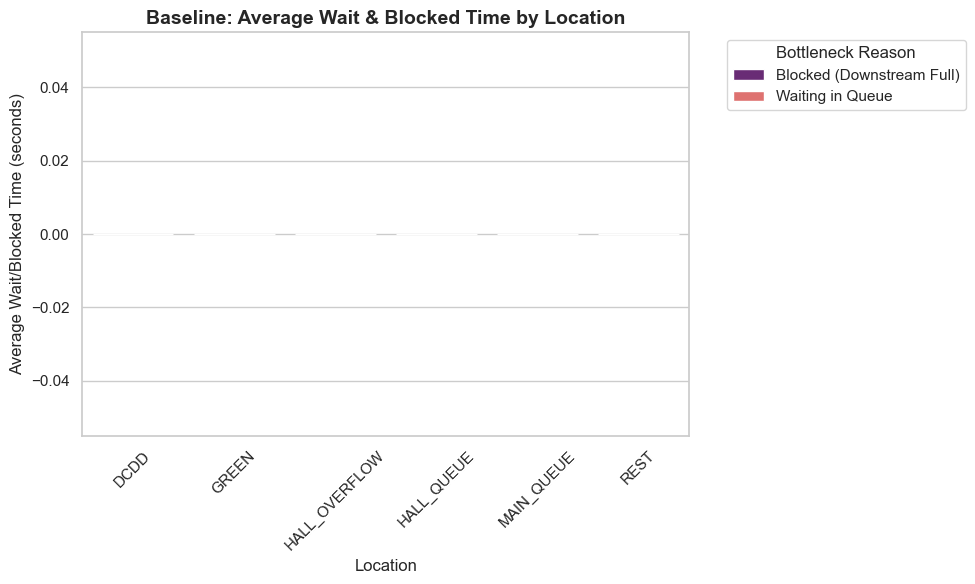

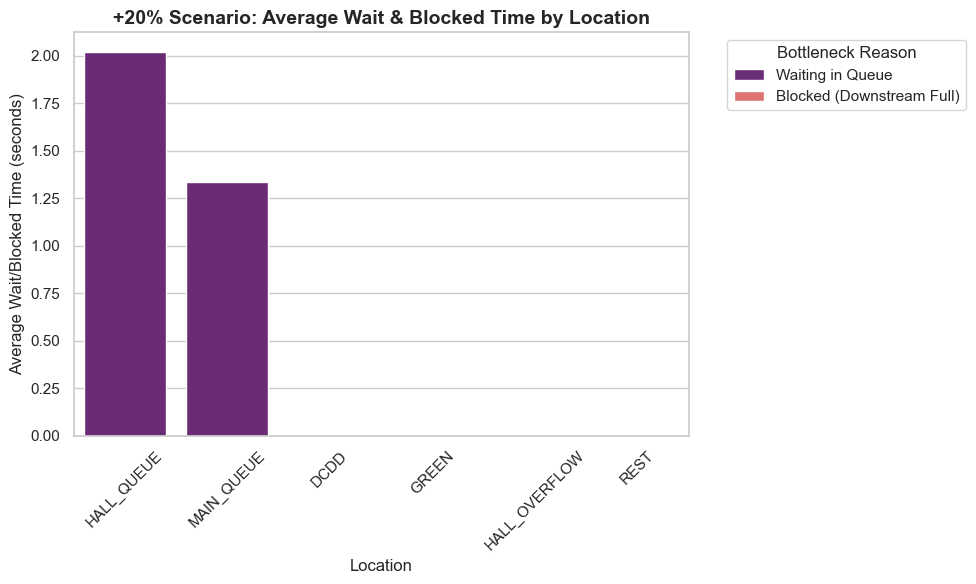

In [164]:
def plot_wait_times(df, title):
    # Exclude the EXIT node to prevent skewed data
    df_filtered = df[df['location'] != 'EXIT'].copy()
    
    # Categorize the wait time based on how the DSE engine handles it
    # If service_time is 0, it's a Queue. Otherwise, it's a Service Bay.
    df_filtered['Wait Type'] = df_filtered['service_time'].apply(
        lambda x: 'Waiting in Queue' if x == 0 else 'Blocked (Downstream Full)'
    )
    
    # Group by both location and the new Wait Type
    wait_summary = df_filtered.groupby(['location', 'Wait Type'])['wait_time'].mean().reset_index()
    wait_summary = wait_summary.sort_values(by='wait_time', ascending=False)
    
    plt.figure(figsize=(10, 6))
    
    # We use dodge=False because each location only has one type of wait. 
    # This centers the bars nicely while still applying the color coding.
    sns.barplot(
        data=wait_summary, 
        x='location', 
        y='wait_time', 
        hue='Wait Type', 
        dodge=False, 
        palette='magma'
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Average Wait/Blocked Time (seconds)', fontsize=12)
    plt.xlabel('Location', fontsize=12)
    plt.xticks(rotation=45)
    
    # Move the legend outside the plot area
    plt.legend(title='Bottleneck Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Run it!
plot_wait_times(df_base, 'Baseline: Average Wait & Blocked Time by Location')
plot_wait_times(df_inc, '+20% Scenario: Average Wait & Blocked Time by Location')

### 2. Queue Length Over Time (Step Plot)

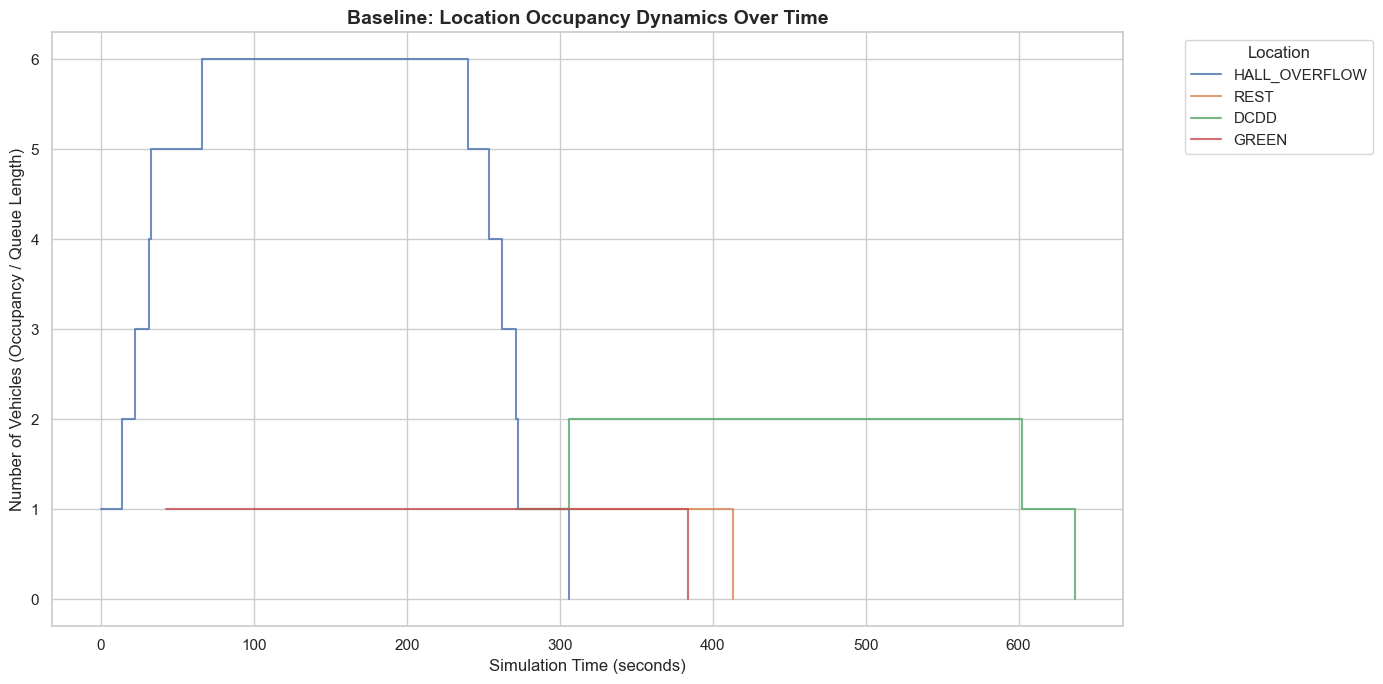

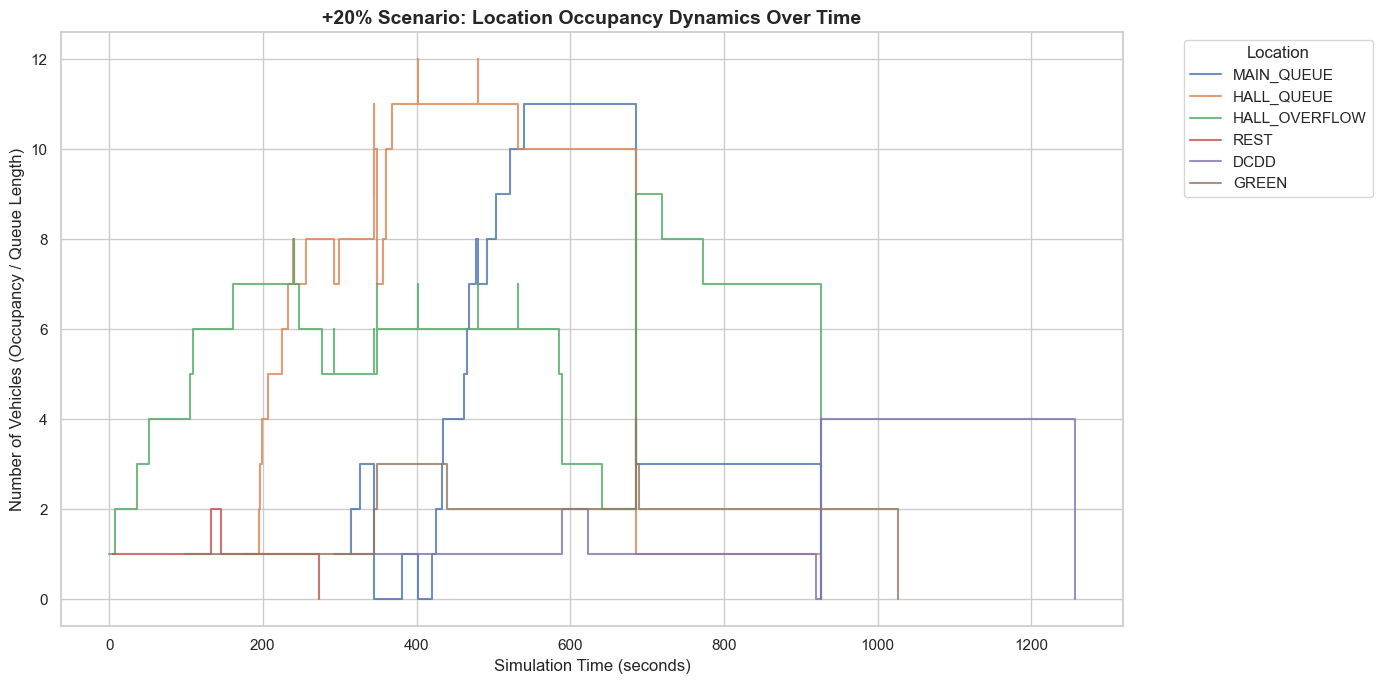

In [165]:
def plot_occupancy_dynamics(df, title):
    # Exclude the EXIT node
    locations = [loc for loc in df['location'].unique() if loc != 'EXIT']
    
    plt.figure(figsize=(14, 7))
    
    for loc in locations:
        # Filter for the specific location and EXCLUDE instant pass-throughs 
        # (If start_time == end_time, they spent 0 seconds there. Plotting it just creates noise)
        loc_df = df[(df['location'] == loc) & (df['start_time'] < df['end_time'])]
        
        if loc_df.empty:
            continue
            
        # +1 when arriving at the location
        arrivals = pd.DataFrame({'time': loc_df['start_time'], 'change': 1})
        # -1 when leaving the location entirely
        departures = pd.DataFrame({'time': loc_df['end_time'], 'change': -1})
        
        # Combine, sort chronologically, and calculate cumulative sum
        events = pd.concat([arrivals, departures]).sort_values(by=['time', 'change'], ascending=[True, False])
        events['occupancy'] = events['change'].cumsum()
        
        # Use a step plot for accurate capacity visualization
        plt.step(events['time'], events['occupancy'], where='post', label=loc, alpha=0.8, linewidth=1.5)
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Simulation Time (seconds)', fontsize=12)
    plt.ylabel('Number of Vehicles (Occupancy / Queue Length)', fontsize=12)
    plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run it!
plot_occupancy_dynamics(df_base, 'Baseline: Location Occupancy Dynamics Over Time')
plot_occupancy_dynamics(df_inc, '+20% Scenario: Location Occupancy Dynamics Over Time')

### 3. Total System Turnaround Time

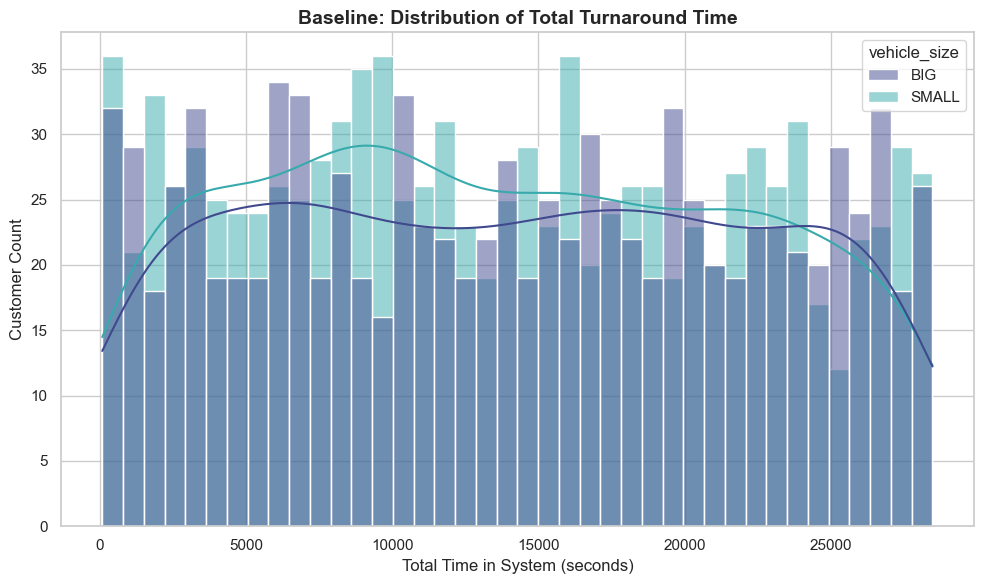

Average Total Time in System: 13908.71 seconds
Maximum Total Time in System: 28482.93 seconds


In [166]:
def plot_turnaround_time(df, title):
    sys_time = df.groupby('customer_id').agg(
        entry_time=('start_time', 'min'),
        exit_time=('end_time', 'max'),
        vehicle_size=('vehicle_size', 'first')
    )
    
    sys_time['total_time'] = sys_time['exit_time'] - sys_time['entry_time']
    
    plt.figure(figsize=(10, 6))
    sns.histplot(data=sys_time, x='total_time', hue='vehicle_size', bins=40, kde=True, palette='mako')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Total Time in System (seconds)', fontsize=12)
    plt.ylabel('Customer Count', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"Average Total Time in System: {sys_time['total_time'].mean():.2f} seconds")
    print(f"Maximum Total Time in System: {sys_time['total_time'].max():.2f} seconds")

plot_turnaround_time(df_base, 'Baseline: Distribution of Total Turnaround Time')


In [167]:
import plotly.express as px
import pandas as pd

def build_debugging_visualizer(df, scenario_name="Simulation"):
    """
    Transforms the simulation log into an interactive HTML Gantt chart.
    Accurately splits 'Waiting' and 'Servicing' based on location type.
    """
    viz_data = []
    base_time = pd.Timestamp('2024-01-01 08:00:00') 
    
    for _, row in df.iterrows():
        # Skip the EXIT node or any node where they spent exactly 0 seconds (instant pass-through)
        if row['location'] == 'EXIT' or row['start_time'] == row['end_time']:
            continue 
            
        start_t = row['start_time']
        end_t = row['end_time']
        
        # In your DES, Queues have 0 service time. Service Bays have > 0 service time.
        is_service_bay = row['service_time'] > 0
        
        if not is_service_bay:
            # QUEUE LOGIC: They wait, and then they leave to go downstream.
            viz_data.append({
                'Customer': f"Cust {row['customer_id']} ({row['vehicle_size']})",
                'State': f"WAITING IN QUEUE: {row['location']}",
                'Location': row['location'],
                'Start': base_time + pd.to_timedelta(start_t, unit='s'),
                'Finish': base_time + pd.to_timedelta(end_t, unit='s'),
                'Duration (s)': row['wait_time'],
                'Type': 'Queue Wait'
            })
        else:
            # SERVICE BAY LOGIC: They are serviced FIRST, then wait ONLY if blocked downstream.
            service_end_t = start_t + row['service_time']
            
            # 1. Servicing Block
            viz_data.append({
                'Customer': f"Cust {row['customer_id']} ({row['vehicle_size']})",
                'State': f"SERVICING: {row['location']}",
                'Location': row['location'],
                'Start': base_time + pd.to_timedelta(start_t, unit='s'),
                'Finish': base_time + pd.to_timedelta(service_end_t, unit='s'),
                'Duration (s)': row['service_time'],
                'Type': 'Servicing'
            })
            
            # 2. Blocked Block (Only plots if they couldn't leave immediately after service)
            if row['wait_time'] > 0:
                viz_data.append({
                    'Customer': f"Cust {row['customer_id']} ({row['vehicle_size']})",
                    'State': f"BLOCKED (WAITING DOWNSTREAM): {row['location']}",
                    'Location': row['location'],
                    'Start': base_time + pd.to_timedelta(service_end_t, unit='s'),
                    'Finish': base_time + pd.to_timedelta(end_t, unit='s'),
                    'Duration (s)': row['wait_time'],
                    'Type': 'Blocked'
                })

    viz_df = pd.DataFrame(viz_data)
    
    if viz_df.empty:
        print("No data to visualize.")
        return

    # Build the Plotly Chart
    fig = px.timeline(
        viz_df, 
        x_start="Start", 
        x_end="Finish", 
        y="Customer", 
        color="State",
        hover_data=["Location", "Type", "Duration (s)"],
        title=f"{scenario_name}: Customer Logic Flow Debugger"
    )
    
    fig.update_yaxes(autorange="reversed") # Put Cust 0 at the top
    fig.update_layout(
        xaxis_title="Simulation Time",
        height=max(400, len(df['customer_id'].unique()) * 30), # Auto-scale height
        showlegend=True,
        hovermode="closest"
    )
    
    fig.show()

# Test it on the first 15 customers!
debug_df = df_base[df_base['customer_id'] < 1000]
build_debugging_visualizer(debug_df, "Baseline: First 15 Customers")

In [168]:
import json

def export_for_animator(df, filename="sim_trace.json"):
    df_anim = df[(df['location'] != 'EXIT') & (df['end_time'] > 0)].copy()
    
    customers_data = []
    
    for cid, group in df_anim.groupby('customer_id'):
        v_size = group['vehicle_size'].iloc[0] 
        
        path = []
        for _, row in group.iterrows():
            path.append({
                "location": row['location'],
                "arrive_queue": row['start_time'],
                "start_service": row['queue_exit_time'],
                "finish_service": row['end_time']
            })
            
        customers_data.append({
            "id": int(cid),
            "size": v_size,
            "path": path
        })
        
    with open(filename, 'w') as f:
        json.dump(customers_data, f, indent=2)
        
    print(f"Exported {len(customers_data)} customers to {filename}")

export_for_animator(df_base, "baseline_anim.json")


Exported 2000 customers to baseline_anim.json
